# CLIP model benchmark for on-device iOS image retrieval

Quick-and-dirty inference benchmark for CLIP-style image/text retrieval models, aimed at picking a model small+fast enough for on-device iOS use.

Not production code -- just timing + a sanity-check similarity print for each model, run over the sample images in `../images`.

**Env setup (uv):**
```bash
uv sync
uv run --with jupyter jupyter lab notebooks/benchmark_clip_models.ipynb
```
or select the `.venv` created by `uv sync` as this notebook's kernel.

In [1]:
import time
import statistics
from pathlib import Path

import torch
from PIL import Image

In [2]:
IMAGES_DIR = Path.cwd().parent / "images"
QUERY_TEXTS = [
    "a photo of a person",
    "a photo of a landscape",
    "a photo of food",
    "a photo of a building",
]
WARMUP_RUNS = 2
TIMED_RUNS = 5

In [3]:
def load_images():
    paths = sorted(
        p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")
    )
    if not paths:
        raise FileNotFoundError(f"No images found in {IMAGES_DIR}")
    return paths, [Image.open(p).convert("RGB") for p in paths]


def time_it(fn, warmup=WARMUP_RUNS, runs=TIMED_RUNS):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter() - t0) * 1000)  # ms
    return statistics.mean(times), statistics.stdev(times) if len(times) > 1 else 0.0

Loaded 3 images from /Users/rafiabhista/Documents/code/apple/c3_agentic_ai/trial_models/images: ['IMG_4141.jpg', 'IMG_4277.JPG', 'IMG_4302.jpg']


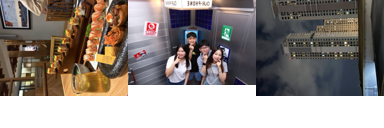

In [4]:
image_paths, images = load_images()
print(f"Loaded {len(images)} images from {IMAGES_DIR}: {[p.name for p in image_paths]}")

# small thumbnail grid just to sanity-check what got loaded (keeps notebook output light)
thumb_row = Image.new("RGB", (128 * len(images), 128), "white")
for i, im in enumerate(images):
    t = im.copy()
    t.thumbnail((128, 128))
    thumb_row.paste(t, (128 * i, 0))
thumb_row

## Model adapters

Each loader returns `(encode_image_fn, encode_text_fn, num_params)`.
- `encode_image_fn(pil_images)` -> normalized tensor `[N, D]`
- `encode_text_fn(texts)` -> normalized tensor `[M, D]`

In [5]:
def load_open_clip(model_name, pretrained):
    import open_clip

    model, _, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    tokenizer = open_clip.get_tokenizer(model_name)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    def encode_images(pil_images):
        batch = torch.stack([preprocess(im) for im in pil_images])
        with torch.no_grad():
            feats = model.encode_image(batch)
            feats /= feats.norm(dim=-1, keepdim=True)
        return feats

    def encode_texts(texts):
        tokens = tokenizer(texts)
        with torch.no_grad():
            feats = model.encode_text(tokens)
            feats /= feats.norm(dim=-1, keepdim=True)
        return feats

    return encode_images, encode_texts, n_params

In [6]:
def load_siglip(model_id):
    from transformers import SiglipModel, SiglipProcessor

    model = SiglipModel.from_pretrained(model_id)
    processor = SiglipProcessor.from_pretrained(model_id)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    def encode_images(pil_images):
        inputs = processor(images=list(pil_images), return_tensors="pt")
        with torch.no_grad():
            feats = model.get_image_features(**inputs).pooler_output
            feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats

    def encode_texts(texts):
        inputs = processor(
            text=texts, return_tensors="pt", padding="max_length", truncation=True
        )
        with torch.no_grad():
            feats = model.get_text_features(**inputs).pooler_output
            feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats

    return encode_images, encode_texts, n_params

## Candidate models

Small/fast (iOS-friendly) -> larger/more accurate baselines. MobileCLIP2 is Apple's own family, purpose-built + CoreML-exportable for iPhone.

In [7]:
MODEL_SPECS = [
    {
        "label": "MobileCLIP2-S0 (Apple, on-device)",
        "loader": lambda: load_open_clip("MobileCLIP2-S0", "dfndr2b"),
    },
    {
        "label": "MobileCLIP2-S2 (Apple, on-device)",
        "loader": lambda: load_open_clip("MobileCLIP2-S2", "dfndr2b"),
    },
    {
        "label": "OpenAI CLIP ViT-B/32 (baseline)",
        "loader": lambda: load_open_clip("ViT-B-32", "openai"),
    },
    {
        "label": "SigLIP base patch16-224 (Google)",
        "loader": lambda: load_siglip("google/siglip-base-patch16-224"),
    },
]

In [8]:
def run_benchmark(spec):
    print(f"=== {spec['label']} ===")
    t0 = time.perf_counter()
    try:
        encode_images, encode_texts, n_params = spec["loader"]()
    except Exception as e:
        print(f"  FAILED to load: {e}\n")
        return None
    load_s = time.perf_counter() - t0
    print(f"  params: {n_params / 1e6:.1f}M | load time: {load_s:.1f}s")

    img_mean, img_std = time_it(lambda: encode_images(images))
    per_image_ms = img_mean / len(images)
    print(
        f"  image encode: {img_mean:.1f}ms +/- {img_std:.1f}ms for "
        f"{len(images)} images ({per_image_ms:.1f}ms/image)"
    )

    txt_mean, txt_std = time_it(lambda: encode_texts(QUERY_TEXTS))
    print(f"  text encode:  {txt_mean:.1f}ms +/- {txt_std:.1f}ms for {len(QUERY_TEXTS)} queries")

    # Sanity check: show top text match per image
    img_feats = encode_images(images)
    txt_feats = encode_texts(QUERY_TEXTS)
    sims = img_feats @ txt_feats.T  # [N images, M texts]
    print("  top match per image:")
    for path, row in zip(image_paths, sims):
        best_idx = row.argmax().item()
        print(f"    {path.name:20s} -> \"{QUERY_TEXTS[best_idx]}\" ({row[best_idx]:.3f})")
    print()

    return {
        "label": spec["label"],
        "params_m": n_params / 1e6,
        "load_s": load_s,
        "ms_per_image": per_image_ms,
        "ms_per_text_batch": txt_mean,
    }

In [9]:
results = [r for r in (run_benchmark(spec) for spec in MODEL_SPECS) if r is not None]

=== MobileCLIP2-S0 (Apple, on-device) ===
  params: 74.8M | load time: 3.3s
  image encode: 304.2ms +/- 1.9ms for 3 images (101.4ms/image)
  text encode:  27.2ms +/- 0.2ms for 4 queries
  top match per image:
    IMG_4141.jpg         -> "a photo of food" (0.239)
    IMG_4277.JPG         -> "a photo of a person" (0.161)
    IMG_4302.jpg         -> "a photo of a building" (0.260)

=== MobileCLIP2-S2 (Apple, on-device) ===
  params: 99.2M | load time: 1.6s
  image encode: 703.8ms +/- 4.5ms for 3 images (234.6ms/image)
  text encode:  24.7ms +/- 0.2ms for 4 queries
  top match per image:
    IMG_4141.jpg         -> "a photo of food" (0.261)
    IMG_4277.JPG         -> "a photo of a person" (0.168)
    IMG_4302.jpg         -> "a photo of a building" (0.271)

=== OpenAI CLIP ViT-B/32 (baseline) ===


/Users/rafiabhista/Documents/code/apple/c3_agentic_ai/trial_models/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  params: 151.3M | load time: 1.8s
  image encode: 102.9ms +/- 1.2ms for 3 images (34.3ms/image)
  text encode:  28.6ms +/- 0.2ms for 4 queries
  top match per image:
    IMG_4141.jpg         -> "a photo of food" (0.248)
    IMG_4277.JPG         -> "a photo of a person" (0.215)
    IMG_4302.jpg         -> "a photo of a building" (0.264)

=== SigLIP base patch16-224 (Google) ===


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

  params: 203.2M | load time: 4.7s
  image encode: 136.6ms +/- 0.6ms for 3 images (45.5ms/image)
  text encode:  43.9ms +/- 2.9ms for 4 queries
  top match per image:
    IMG_4141.jpg         -> "a photo of food" (0.080)
    IMG_4277.JPG         -> "a photo of a building" (0.023)
    IMG_4302.jpg         -> "a photo of a building" (0.073)



## Summary

In [10]:
header = f"{'Model':38s} {'Params(M)':>10s} {'Load(s)':>8s} {'ms/img':>8s} {'ms/text-batch':>14s}"
print(header)
for r in results:
    print(
        f"{r['label']:38s} {r['params_m']:10.1f} {r['load_s']:8.1f} "
        f"{r['ms_per_image']:8.1f} {r['ms_per_text_batch']:14.1f}"
    )

Model                                   Params(M)  Load(s)   ms/img  ms/text-batch
MobileCLIP2-S0 (Apple, on-device)            74.8      3.3    101.4           27.2
MobileCLIP2-S2 (Apple, on-device)            99.2      1.6    234.6           24.7
OpenAI CLIP ViT-B/32 (baseline)             151.3      1.8     34.3           28.6
SigLIP base patch16-224 (Google)            203.2      4.7     45.5           43.9
